# Binary Tree — Basics se LeetCode tak

Is notebook mein yeh sab cover hoga:
1. TreeNode class + tree banana
2. Tree ko print/visualize karna
3. Traversals — Inorder, Preorder, Postorder, Level-order
4. Basic operations — Height, Count, Search
5. LeetCode ke common patterns

> **Rule:** Pehla cell hamesha run karo — baaki sab uspe depend karta hai.

## CELL 1 — Foundation (Hamesha run karo)

| Step | Node Popped | i (before) | Left Value | Action Taken        | Right Value | Action Taken         | Queue After       |
|------|-------------|------------|------------|---------------------|-------------|----------------------|-------------------|
| 1    | 1           | 1          | 2          | 1.left = 2          | 3           | 1.right = 3          | [2, 3]            |
| 2    | 2           | 3          | 4          | 2.left = 4          | 5           | 2.right = 5          | [3, 4, 5]         |
| 3    | 3           | 5          | None       | skip                | 6           | 3.right = 6          | [4, 5, 6]         |

In [31]:
from typing import Optional, List
from collections import deque

# ── TreeNode: ek node ka structure ──────────────────────────────────────────
#
#        [val]
#       /     \
#   [left]  [right]
#
class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val   = val    # node ki value
        self.left  = left   # left child (TreeNode ya None)
        self.right = right  # right child (TreeNode ya None)

    def __repr__(self):
        return f"TreeNode({self.val})"


# ── build(): LeetCode-style list se tree banana ──────────────────────────────
#
#   build([1, 2, 3, 4, 5, None, 6])
#
#           1          level 0
#          / \
#         2   3        level 1
#        / \   \
#       4   5   6      level 2
#
def build(vals):
    """Build tree from level-order list, None = missing node."""
    if not vals or vals[0] is None:
        return None
    root = TreeNode(vals[0]) #1
    q = deque([root]) #1=> nodes whose children we still need to fill
    i = 1 # index i → to read the list
    while q and i < len(vals):
        node = q.popleft() #1,2
        if i < len(vals) and vals[i] is not None:
            node.left = TreeNode(vals[i]) # 1.left =TreeNode(2)
            q.append(node.left) #2
        i += 1 #2
        if i < len(vals) and vals[i] is not None:
            node.right = TreeNode(vals[i]) # 1.right =3
            q.append(node.right) #[2,3]
        i += 1 #3
    return root


# ── print_tree(): tree ko visually dikhana ───────────────────────────────────
def print_tree(root, prefix="", is_left=True):
    """Tree ko sideways print karta hai (rotate karke dekho)."""
    if root is None:
        return
    print_tree(root.right, prefix + ("│   " if is_left else "    "), False)
    print(prefix + ("└── " if is_left else "┌── ") + str(root.val))
    print_tree(root.left,  prefix + ("    " if is_left else "│   "), True)


print("✓ Foundation load ho gaya!")

✓ Foundation load ho gaya!


---
## CELL 2 — Tree Banana (3 Tarike)

```
       1
      / \
     2   3
    / \   \
   4   5   6
```

In [32]:
# ── Tarika 1: Manually (samajhne ke liye) ───────────────────────────────────
root_manual = TreeNode(1)
root_manual.left         = TreeNode(2)
root_manual.right        = TreeNode(3)
root_manual.left.left    = TreeNode(4)
root_manual.left.right   = TreeNode(5)
root_manual.right.right  = TreeNode(6)

print("Manual tree:")
print_tree(root_manual)

print()

# ── Tarika 2: build() se — LeetCode input format ─────────────────────────────
#   None = woh position empty hai
root = build([1, 2, 3, 4, 5, None, 6])

print("build() se bana tree:")
print_tree(root)

print()

# ── Tarika 3: Edge cases ─────────────────────────────────────────────────────
single = build([42])          # sirf root
empty  = build([])            # empty tree

print(f"Single node: {single}")   # TreeNode(42)
print(f"Empty tree:  {empty}")    # None

Manual tree:
│       ┌── 6
│   ┌── 3
└── 1
    │   ┌── 5
    └── 2
        └── 4

build() se bana tree:
│       ┌── 6
│   ┌── 3
└── 1
    │   ┌── 5
    └── 2
        └── 4

Single node: TreeNode(42)
Empty tree:  None


---
## CELL 3 — Traversals (Sabse Important!)

Traversal = tree ke **har node pe jaana** ek specific order mein.

```
       1
      / \
     2   3
    / \
   4   5
```

| Traversal   | Order             | Result        | Trick |
|-------------|-------------------|---------------|-------|
| Inorder     | Left → Root → Right | [4,2,5,1,3] | BST mein sorted order deta hai |
| Preorder    | Root → Left → Right | [1,2,4,5,3] | Tree copy/serialize karne ke liye |
| Postorder   | Left → Right → Root | [4,5,2,3,1] | Tree delete karne ke liye |
| Level-order | Level by level    | [1,2,3,4,5]   | BFS — shortest path problems |

| Step | Queue Before | Node Popped | Result After Append | Queue After Adding Children |
|------|--------------|-------------|---------------------|-----------------------------|
| 1    | [1]          | 1           | [1]                 | [2, 3]                      |
| 2    | [2, 3]       | 2           | [1, 2]              | [3, 4, 5]                   |
| 3    | [3, 4, 5]    | 3           | [1, 2, 3]           | [4, 5]                      |
| 4    | [4, 5]       | 4           | [1, 2, 3, 4]        | [5]                         |
| 5    | [5]          | 5           | [1, 2, 3, 4, 5]     | []                          |

In [33]:
root = build([1, 2, 3, 4, 5])
#       1
#      / \
#     2   3
#    / \
#   4   5


# ── Inorder: Left → Root → Right ─────────────────────────────────────────────
def inorder(root):
    if root is None:          # base case: koi node nahi → ruk jao
        return []
    return inorder(root.left) + [root.val] + inorder(root.right)
    #      pehle left          phir root     phir right


# ── Preorder: Root → Left → Right ────────────────────────────────────────────
def preorder(root):
    if root is None:
        return []
    return [root.val] + preorder(root.left) + preorder(root.right)
    #       pehle root   phir left             phir right


# ── Postorder: Left → Right → Root ───────────────────────────────────────────
def postorder(root):
    if root is None:
        return []
    return postorder(root.left) + postorder(root.right) + [root.val]
    #       pehle left             phir right              aakhir mein root


# ── Level-order (BFS): Level by level ────────────────────────────────────────
def level_order(root):
    if root is None:
        return []
    result = []
    q = deque([root])         # queue mein root daalo
    while q:
        node = q.popleft()    # agla node nikalo
        result.append(node.val)
        if node.left:         # left child hai to queue mein daalo
            q.append(node.left)
        if node.right:        # right child hai to queue mein daalo
            q.append(node.right)
    return result


print("Tree:")
print_tree(root)
print()
print(f"Inorder   (L→Root→R): {inorder(root)}")
print(f"Preorder  (Root→L→R): {preorder(root)}")
print(f"Postorder (L→R→Root): {postorder(root)}")
print(f"Level-order (BFS)   : {level_order(root)}")

Tree:
│   ┌── 3
└── 1
    │   ┌── 5
    └── 2
        └── 4

Inorder   (L→Root→R): [4, 2, 5, 1, 3]
Preorder  (Root→L→R): [1, 2, 4, 5, 3]
Postorder (L→R→Root): [4, 5, 2, 3, 1]
Level-order (BFS)   : [1, 2, 3, 4, 5]


---
## CELL 4 — Recursion Samajhna (DFS ka Core)

Almost **sabhi tree problems recursion se solve hote hain**.

### Formula:
```
def solve(root):
    if root is None:          # ← Base case: leaf ke baad kuch nahi
        return ...            #   (kya return karna hai empty ke liye?)
    
    left  = solve(root.left)  # ← left subtree ka jawab lo
    right = solve(root.right) # ← right subtree ka jawab lo
    
    return ... left, right, root.val ...  # ← combine karke return karo
```

### Socho aise:
> "Mujhe sirf **ek node** ke liye kya karna hai? Baaki recursion sambhal lega."

In [34]:
root = build([3, 9, 20, None, None, 15, 7])
#         3
#        / \
#       9   20
#          /  \
#         15   7


# ── Height / Max Depth ───────────────────────────────────────────────────────
# Socho: "Ek node ki height = 1 + max(left height, right height)"
def height(root):
    if root is None:
        return 0                              # empty tree ki height = 0
    left_h  = height(root.left)
    right_h = height(root.right)
    return 1 + max(left_h, right_h)          # current node + bada wala side


# ── Node Count ───────────────────────────────────────────────────────────────
# Socho: "Nodes = 1 (root) + left ke nodes + right ke nodes"
def count_nodes(root):
    if root is None:
        return 0
    return 1 + count_nodes(root.left) + count_nodes(root.right)


# ── Search ───────────────────────────────────────────────────────────────────
# Socho: "Kya yeh node hai? Nahi to left ya right mein dhundo"
def search(root, target):
    if root is None:
        return False                          # nahi mila
    if root.val == target:
        return True                           # mil gaya!
    return search(root.left, target) or search(root.right, target)


# ── Sum of all nodes ─────────────────────────────────────────────────────────
def tree_sum(root):
    if root is None:
        return 0
    return root.val + tree_sum(root.left) + tree_sum(root.right)


print("Tree:")
print_tree(root)
print()
print(f"Height      : {height(root)}")
print(f"Node count  : {count_nodes(root)}")
print(f"Sum         : {tree_sum(root)}")
print(f"Search 15   : {search(root, 15)}")
print(f"Search 99   : {search(root, 99)}")

Tree:
│       ┌── 7
│   ┌── 20
│   │   └── 15
└── 3
    └── 9

Height      : 3
Node count  : 5
Sum         : 54
Search 15   : True
Search 99   : False


---
## CELL 5 — Level-order (BFS) — Level-wise Results
## LeetCode 102 – Binary Tree Level Order Traversal

Kai LeetCode problems mein har level ka result alag chahiye hota hai.

```
       3          → level 0: [3]
      / \
     9   20       → level 1: [9, 20]
        /  \
       15   7     → level 2: [15, 7]
```
Output: `[[3], [9,20], [15,7]]`

| Step | Queue Before | level_size | Pop | Level (after) | Queue After Adding Children | Result |
|------|--------------|------------|-----|----------------|-----------------------------|--------|
| 1    | [3]          | 1          | 3   | [3]            | [9, 20]                     | [[3]] |
| 2    | [9, 20]      | 2          | 9   | [9]            | [20]                        | [[3]] |
| 3    | [20]         | 2          | 20  | [9, 20]        | [15, 7]                     | [[3],[9,20]] |
| 4    | [15, 7]      | 2          | 15  | [15]           | [7]                         | [[3],[9,20]] |
| 5    | [7]          | 2          | 7   | [15, 7]        | []                          | [[3],[9,20],[15,7]] |

In [35]:
root = build([3, 9, 20, None, None, 15, 7])


# ── Level-wise list of lists ──────────────────────────────────────────────────
def level_order_levels(root):
    if root is None:
        return []
    result = []
    q = deque([root])
    while q:
        level_size = len(q)       # is level mein kitne nodes hain
        level = []
        for _ in range(level_size):
            node = q.popleft()
            level.append(node.val)
            if node.left:  q.append(node.left)
            if node.right: q.append(node.right)
        result.append(level)
    return result


# ── Har level ki max value ────────────────────────────────────────────────────
def level_max(root):
    return [max(level) for level in level_order_levels(root)]


# ── Right side view (har level ka rightmost node) ─────────────────────────────
def right_side_view(root):
    return [level[-1] for level in level_order_levels(root)]


print("Tree:")
print_tree(root)
print()
print(f"Level-order (levels) : {level_order_levels(root)}")
print(f"Har level ki max     : {level_max(root)}")
print(f"Right side view      : {right_side_view(root)}")

Tree:
│       ┌── 7
│   ┌── 20
│   │   └── 15
└── 3
    └── 9

Level-order (levels) : [[3], [9, 20], [15, 7]]
Har level ki max     : [3, 20, 15]
Right side view      : [3, 20, 7]


---
## CELL 6 — LeetCode ke Top 5 Patterns

Yeh 5 patterns se **80% tree problems** solve ho jaate hain.

In [36]:
# ── Pattern 1: Return value upar bhejo (bottom-up) ───────────────────────────
# LeetCode 104 — Maximum Depth of Binary Tree
# "Leaf se root tak jawab collect karo"

def maxDepth(root: Optional[TreeNode]) -> int:
    if root is None:
        return 0
    return 1 + max(maxDepth(root.left), maxDepth(root.right))


| Step | Function Call | Node | Left Result     | Right Result    | Best Update (diameter) | Return (height) | Explanation                      |
| ---- | ------------- | ---- | --------------- | --------------- | ---------------------- | --------------- | -------------------------------- |
| 1    | dfs(4)        | 4    | 0               | 0               | best = max(0, 0+0) = 0 | 1               | Leaf node → no children          |
| 2    | dfs(5)        | 5    | 0               | 0               | best = max(0, 0+0) = 0 | 1               | Leaf node → no children          |
| 3    | dfs(2)        | 2    | 1 (from node 4) | 1 (from node 5) | best = max(0, 1+1) = 2 | 2               | Node 2 ke through path 4 → 2 → 5 |
| 4    | dfs(3)        | 3    | 0               | 0               | best = max(2, 0+0) = 2 | 1               | Leaf node                        |
| 5    | dfs(1)        | 1    | 2 (from node 2) | 1 (from node 3) | best = max(2, 2+1) = 3 | 3               | Root ke through best path        |


DFS = “pehle ek path pe pura jao, phir backtrack karo”

Like:  
Root pe aaya  
Left subtree ko poora explore kiya  
Phir right subtree

In [37]:

# ── Pattern 2: Global variable mein track karo ───────────────────────────────
# LeetCode 543 — Diameter of Binary Tree
# "Har node pe locally calculate karo, best globally track karo"
# Diameter = longest path between any two nodes
"""     1
       / \
      2   3
     / \
    4   5 
    
    """

def diameterOfBinaryTree(root: Optional[TreeNode]) -> int:
    best = [0]                              # list use karo taaki nested func update kar sake

    def dfs(node):
        if node is None:
            return 0
        left  = dfs(node.left)
        right = dfs(node.right)
        best[0] = max(best[0], left + right)  # is node se guzarne wala diameter
        return 1 + max(left, right)           # parent ko depth bhejo

    dfs(root)
    return best[0]

| Step | p          | q    | p.val | q.val | Condition 1 (both None) | Condition 2 (one None) | Condition 3 (p.val != q.val) | Action        |
| ---- | ---------- | ---- | ----- | ----- | ----------------------- | ---------------------- | ---------------------------- | ------------- |
| 1    | 1          | 1    | 1     | 1     | False                   | False                  | False                        | go deeper     |
| 2    | 2          | 2    | 2     | 2     | False                   | False                  | False                        | go deeper     |
| 3    | None       | None | —     | —     | True                    | —                      | —                            | return True   |
| 4    | None       | None | —     | —     | True                    | —                      | —                            | return True   |
| 5    | back (2,2) | 2    | 2     | 2     | —                       | —                      | —                            | True AND True |
| 6    | 3          | 3    | 3     | 3     | False                   | False                  | False                        | go deeper     |
| 7    | None       | None | —     | —     | True                    | —                      | —                            | return True   |
| 8    | None       | None | —     | —     | True                    | —                      | —                            | return True   |
| 9    | back (3,3) | 3    | 3     | 3     | —                       | —                      | —                            | True AND True |
| 10   | back (1,1) | 1    | 1     | 1     | —                       | —                      | —                            | True AND True |


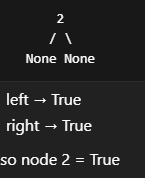

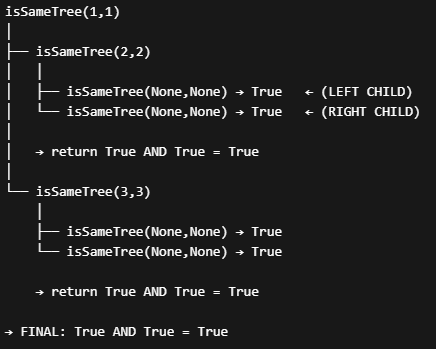

In [38]:
""" 
Tree P
        1
       / \
      2   3

Tree Q
        1
       / \
      2   3
"""

' \nTree P\n        1\n       /       2   3\n\nTree Q\n        1\n       /       2   3\n'

In [ ]:
# ── Pattern 3: Do conditions simultaneously check karo ───────────────────────
# LeetCode 100 — Same Tree
# "Dono trees ko saath-saath traverse karo"

def isSameTree(p: Optional[TreeNode], q: Optional[TreeNode]) -> bool:
    if not p and not q: return True           # dono None → same(na p h na q hai)
    if not p or  not q: return False          # ek None ek nahi → different
    if p.val != q.val:  return False          # values alag → different
    return isSameTree(p.left, q.left) and isSameTree(p.right, q.right)


In [ ]:
# Definition for a binary tree node.
# class TreeNode(object):
#     def __init__(self, val=0, left=None, right=None):
#         self.val = val
#         self.left = left
#         self.right = right

class Solution(object):
    def isSameTree(self, p, q):
        """
        :type p: Optional[TreeNode]
        :type q: Optional[TreeNode]
        :rtype: bool
        """

        if not p and not q:
            return True

        if not p or not q:
            return False

        if p.val != q.val: # kya 1 aur 1 equal NAHI hain?
            return False # nahi

        return self.isSameTree(p.left, q.left) and self.isSameTree(p.right, q.right)

| Step | Node       | Incoming Target | After Subtract | Leaf? | Check         | Return  |
| ---- | ---------- | --------------- | -------------- | ----- | ------------- | ------- |
| 1    | 5          | 22              | 17             | No    | go down       | pending |
| 2    | 4          | 17              | 13             | No    | go down       | pending |
| 3    | 11         | 13              | 2              | No    | go down       | pending |
| 4    | 7          | 2               | -5             | Yes   | -5 == 0 ❌     | False   |
| 5    | 2          | 2               | 0              | Yes   | 0 == 0 ✅      | True    |
| 6    | back to 11 | —               | —              | —     | False OR True | True    |
| 7    | back to 4  | —               | —              | —     | True          | True    |
| 8    | back to 5  | —               | —              | —     | True          | True    |


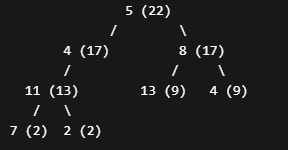

Start: 22  
path :-5 → 4 → 11 → 2  
5  → 22 - 5  = 17    
4  → 17 - 4  = 13    
11 → 13 - 11 = 2    
2  → 2  - 2  = 0  ✅  
👉 Leaf pe 0 → RETURN TRUE

❌ FAILED PATH   
5 → 4 → 11 → 7  
22 - 5 = 17     
17 - 4 = 13    
13 - 11 = 2    
2  - 7 = -5 ❌  

👉 Leaf pe ≠ 0 → False

Left subtree = True  
Right subtree = False  

True OR False = True

In [43]:
# ── Pattern 4: Path tracking ─────────────────────────────────────────────────
# LeetCode 112 — Path Sum
# "Root se leaf tak jaate hue kuch track karo"

class Solution(object):
    def hasPathSum(self, root, targetSum):
        if root is None:
            return False

        targetSum -= root.val                                   # current node ki value minus karo
        if not root.left and not root.right:                    # leaf node pe pahunch gaye
            return targetSum == 0                               # kya sum poora hua?
        return self.hasPathSum(root.left, targetSum) or self.hasPathSum(root.right, targetSum)



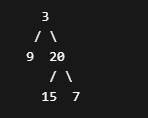

| Step        | Queue Start | level_size | Node Popped | Level List | Queue After | res                 |
| ----------- | ----------- | ---------- | ----------- | ---------- | ----------- | ------------------- |
| 1           | [3]         | 1          | 3           | [3]        | [9,20]      | []                  |
| → end level | —           | —          | —           | —          | —           | [[3]]               |
| 2           | [9,20]      | 2          | 9           | [9]        | [20]        | [[3]]               |
| 3           | [20]        | —          | 20          | [9,20]     | [15,7]      | [[3]]               |
| → end level | —           | —          | —           | —          | —           | [[3],[9,20]]        |
| 4           | [15,7]      | 2          | 15          | [15]       | [7]         | [[3],[9,20]]        |
| 5           | [7]         | —          | 7           | [15,7]     | []          | [[3],[9,20]]        |
| → end level | —           | —          | —           | —          | —           | [[3],[9,20],[15,7]] |


In [47]:


# ── Pattern 5: Level-order (BFS) ─────────────────────────────────────────────
# LeetCode 102 — Binary Tree Level Order Traversal
# (Upar bana chuke hain — level_order_levels())

from collections import deque

class Solution(object):
    def levelOrder(self, root):
        if not root:
            return []
        
        res = []
        queue = deque([root])
        
        while queue:
            level_size = len(queue)
            level = []
            
            for _ in range(level_size):
                node = queue.popleft()
                level.append(node.val)
                
                if node.left:
                    queue.append(node.left)
                if node.right:
                    queue.append(node.right)
            
            res.append(level)
        
        return res



In [46]:

# ── Tests ────────────────────────────────────────────────────────────────────
t1 = build([3, 9, 20, None, None, 15, 7])
t2 = build([1, 2, 2, 3, 4, 4, 3])
t3 = build([5, 4, 8, 11, None, 13, 4, 7, 2, None, None, None, 1])

print(f"maxDepth         : {maxDepth(t1)}")              # 3
print(f"diameter         : {diameterOfBinaryTree(t1)}")  # 3
print(f"isSameTree       : {isSameTree(t2, t2)}")        # True
print(f"hasPathSum 22    : {hasPathSum(t3, 22)}")         # True
print(f"level_order      : {level_order_levels(t1)}")    # [[3],[9,20],[15,7]]

maxDepth         : 3
diameter         : 3
isSameTree       : True
hasPathSum 22    : True
level_order      : [[3], [9, 20], [15, 7]]


---
## CELL 7 — Quick Reference (Cheat Sheet)

```
TRAVERSALS:
  Inorder   → Left, Root, Right   → BST mein sorted order
  Preorder  → Root, Left, Right   → Tree copy karna
  Postorder → Left, Right, Root   → Tree delete karna
  BFS       → Level by level      → Shortest path

RECURSION TEMPLATE:
  def solve(root):
      if root is None: return <base_value>
      left  = solve(root.left)
      right = solve(root.right)
      return <combine left, right, root.val>

BFS TEMPLATE:
  q = deque([root])
  while q:
      node = q.popleft()
      if node.left:  q.append(node.left)
      if node.right: q.append(node.right)

LEETCODE PE SUBMIT KARTE WAQT:
  → Sirf function copy karo
  → TreeNode, build(), print_tree() mat copy karo
  → LeetCode khud TreeNode provide karta hai

TOP PATTERNS:
  1. Bottom-up return   → maxDepth, minDepth
  2. Global variable    → diameter, maxPathSum
  3. Two-pointer trees  → isSameTree, isSymmetric
  4. Path tracking      → hasPathSum, pathSum
  5. BFS level-order    → levelOrder, rightSideView
```

In [ ]:
# ── Sab ek saath test karo ───────────────────────────────────────────────────
root = build([1, 2, 3, 4, 5, None, 6])

print("Tree:")
print_tree(root)
print()
print(f"Inorder     : {inorder(root)}")
print(f"Preorder    : {preorder(root)}")
print(f"Postorder   : {postorder(root)}")
print(f"Level-order : {level_order(root)}")
print(f"Height      : {height(root)}")
print(f"Nodes       : {count_nodes(root)}")
print(f"Sum         : {tree_sum(root)}")

Tree:
│       ┌── 6
│   ┌── 3
└── 1
    │   ┌── 5
    └── 2
        └── 4

Inorder     : [4, 2, 5, 1, 3, 6]
Preorder    : [1, 2, 4, 5, 3, 6]
Postorder   : [4, 5, 2, 6, 3, 1]
Level-order : [1, 2, 3, 4, 5, 6]
Height      : 3
Nodes       : 6
Sum         : 21
